Tarea 3

Juan Acevedo Fuentes

2020770859

20-05-2025

<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

In [6]:
df = pd.read_csv('../../../data/junaeb3.csv')

In [7]:
df.isnull().sum()

sexo             0
edad             0
imce             0
vive_padre       0
vive_madre       0
sk1              0
sk2              0
sk3              0
sk4              0
sk5              0
sk6              0
sk7              0
sk8              0
sk9              0
sk10             0
sk11             0
sk12             0
sk13             0
act_fisica    1004
area             0
educm          373
educp            0
madre_work       0
dtype: int64

La base de datos no presenta datos perdidos exceptuando las variables de actividad fisica y educm. los cuales representan menos de un 4% de toda la data. Debido a que los siguientes analisis se realizaran con otras variables por el momento no se eliminaran

<Axes: >

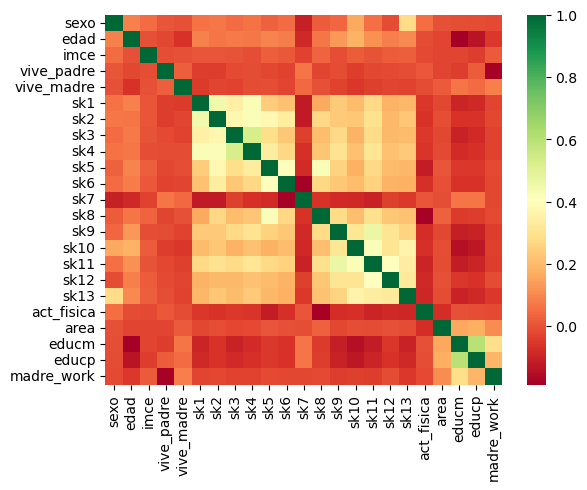

In [8]:
df.sk7 = 6 - df.sk7
sns.heatmap(df.corr() ,cmap='RdYlGn', )

AL realizar el mapa de calor de las correlaciones de las varibles podemos identificar que las variables no sk suelen no relacionarse entre si excepto el nivel educativo de los padres presentan una correlacion del 0.6 aproximadamente, esto puede darnos una pista que los padres suelen emparejarse los que posean un nivel educativo similar.

Ahora hablando respecto a las variables sk podemos ver que conservan una correlacion al rededor de 0.2, excepto por sk7 debido a su condicion de ser un concepto negativo ante las demas respuestas. Aun invirtiendo la variable sk7 sigue si correlacionarse con los demás. Entre la variable sk3 y 4 vemos que posee una relacion de 0.5 aproximadamente, esto puede ser explicado porque las preguntas son muy similares o van en la misma sintonia

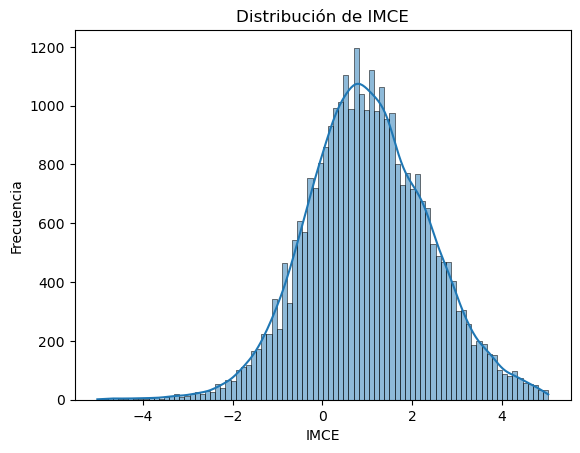

minimo: -5.02 maximo: 5.04


In [9]:
sns.histplot(df, x='imce', kde=True)
plt.title('Distribución de IMCE')
plt.xlabel('IMCE')
plt.ylabel('Frecuencia')
plt.show()
print('minimo:',df['imce'].min(),'maximo:' ,df['imce'].max())

La variable imce parece distribuir de una manera casi normal aunque hay menos resultados negativos osea habrian menos personas debajo de un imc promedio que los que superan el promedio. Ademas vemos que la media de los datos esta por sobre el imc promedio que sería 0, por lo que se concluye que los niños suelen poseer un pequeño grado de obecidad sobre el promedio estandarizado.

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [10]:
df1 = df[['sk1','sk2','sk3','sk4','sk5','sk6','sk7','sk8','sk9','sk10','sk11','sk12','sk13']]
df1.describe()

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000
mean,1.114088,1.391177,1.262856,1.256352,1.268588,1.490130,3.762905,1.556754,1.333666,1.853743,1.385349,1.502785,1.694735
std,0.394004,0.650190,0.585766,0.578266,0.564929,0.741772,1.214981,0.834809,0.666009,0.941171,0.668783,0.799375,0.984946
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,5.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation='varimax').fit(df1)

In [12]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.183970, 0.549198, 0.155598],
       [0.177203, 0.517433, 0.350410],
       [0.182944, 0.596588, 0.168045],
       [0.198779, 0.686060, 0.200987],
       [0.121309, 0.219980, 0.724979],
       [0.173086, 0.210702, 0.481159],
       [-0.069524, -0.074626, -0.136478],
       [0.269342, 0.104813, 0.478344],
       [0.495931, 0.215337, 0.207927],
       [0.563365, 0.122575, 0.127228],
       [0.664883, 0.209988, 0.205834],
       [0.526984, 0.116246, 0.144172],
       [0.485171, 0.154101, 0.134872]])

In [13]:
fa.get_eigenvalues()

(array([4.114952, 1.341624, 1.100575, 1.000161, 0.781977, 0.698537,
        0.695787, 0.684453, 0.604042, 0.523209, 0.512081, 0.487796,
        0.454807]),
 array([3.526388, 0.743955, 0.517426, 0.211290, 0.114533, 0.062767,
        0.008348, -0.008400, -0.035529, -0.060437, -0.080399, -0.084919,
        -0.127254]))

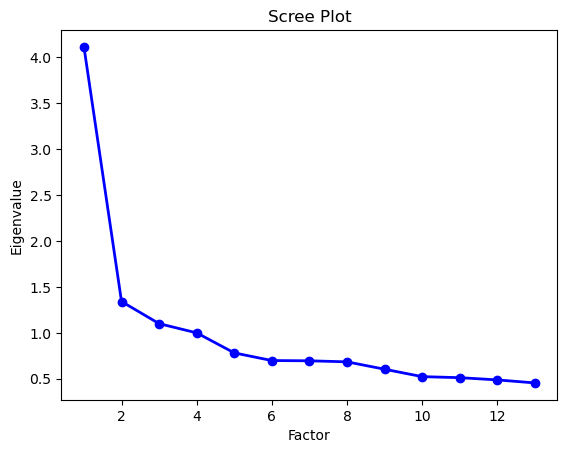

In [14]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

Segun los valores propios podemos ver qué según el criterio de kaiser, deben haber 4 factores

In [15]:
#Ver la que tan explicadas son las variables segun los factores. de 2 a 0 es poco explicado
fa.get_communalities()

array([0.359674, 0.421925, 0.417625, 0.550587, 0.588702, 0.305868,
       0.029029, 0.312344, 0.335551, 0.348592, 0.528531, 0.312011,
       0.277328])

Al revisar el que tan bien explicadas son las variables entre los factores vemos como claramente sk7 es cercano a 0. Por lo que para los analisis siguientes no es influyente o no es representativo en los factor. Esta situacion puede explicarse debido a la alta diferencia que hay entre las demas preguntas y sk7, debido a que las demas son preguntas con una intencionalidad positiva y en cambio sk7 encuesta la agresividad del niño, puede que haciendo mas preguntas de indole negativo entregen la posibilidad de incluir otro factor mas al analisis.

Extrañamente los resultados automaticos distan del resultado analitico de cuantos factores incluir, 3 y 4 respectivamente. Forcemos al modelo a incluir 4 factores para ver sus diferencias.

In [16]:
fa4 = FactorAnalyzer(rotation='varimax', n_factors=4).fit(df1)

sk_vars = [f'sk{i}' for i in range(1, 14)]
loadings = pd.DataFrame(fa4.loadings_, index=sk_vars, columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4'])
print("Cargas factoriales (factor loadings):")
print(loadings.round(2))

# Variables asociadas a cada factor según cargas factoriales
factor_dict = {}

for i in range(4):
    factor_name = f'Factor {i+1}'
    variables = loadings[loadings.iloc[:,i].abs() > 0.4].index.tolist()
    factor_dict[factor_name] = variables

factor_table = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in factor_dict.items()]))
print("Variables asociadas a cada factor:")
display(factor_table)

Cargas factoriales (factor loadings):
      Factor 1  Factor 2  Factor 3  Factor 4
sk1       0.18      0.52      0.06      0.32
sk2       0.17      0.49      0.26      0.37
sk3       0.20      0.63      0.17     -0.03
sk4       0.22      0.70      0.19      0.04
sk5       0.14      0.23      0.74      0.13
sk6       0.18      0.18      0.41      0.31
sk7      -0.06     -0.03     -0.06     -0.30
sk8       0.29      0.12      0.46      0.07
sk9       0.51      0.21      0.19      0.05
sk10      0.57      0.09      0.07      0.17
sk11      0.67      0.19      0.17      0.12
sk12      0.53      0.12      0.13      0.03
sk13      0.49      0.14      0.11      0.09
Variables asociadas a cada factor:


,Factor 1,Factor 2,Factor 3,Factor 4
0,sk9,sk1,sk5,NaN
1,sk10,sk2,sk6,NaN
2,sk11,sk3,sk8,NaN
3,sk12,sk4,NaN,NaN
4,sk13,NaN,NaN,NaN


Según lo visto podemos apreciar que el factor 4 no presenta ninguna variable. Por lo que podemos conlcuir que 3 factores es mas que suficiente para poder continuar con nuestros analisis.

In [17]:
# Ajustar el EFA con 3 factores y mostrar las cargas factoriales
fa3 = FactorAnalyzer(n_factors=3, rotation='promax').fit(df1)

sk_vars = [f'sk{i}' for i in range(1, 14)]
loadings2 = pd.DataFrame(fa3.loadings_, index=sk_vars, columns=['Factor 1', 'Factor 2', 'Factor 3'])
print("Cargas factoriales (factor loadings):")
print(loadings2.round(2))

# Variables asociadas a cada factor según cargas factoriales
factor_dict2 = {}

for i in range(3):
    factor_name2 = f'Factor {i+1}'
    variables2 = loadings2[loadings2.iloc[:,i].abs() > 0.4].index.tolist()
    factor_dict2[factor_name2] = variables2

factor_table2 = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in factor_dict2.items()]))
print("Variables asociadas a cada factor:")
display(factor_table2)

Cargas factoriales (factor loadings):
      Factor 1  Factor 2  Factor 3
sk1       0.03      0.61     -0.04
sk2      -0.03      0.49      0.24
sk3       0.01      0.66     -0.04
sk4      -0.00      0.76     -0.03
sk5      -0.15     -0.02      0.86
sk6      -0.00      0.05      0.52
sk7      -0.02     -0.03     -0.14
sk8       0.15     -0.11      0.53
sk9       0.49      0.08      0.06
sk10      0.63     -0.03     -0.04
sk11      0.70      0.03      0.01
sk12      0.58     -0.03     -0.00
sk13      0.52      0.03     -0.01
Variables asociadas a cada factor:


,Factor 1,Factor 2,Factor 3
0,sk9,sk1,sk5
1,sk10,sk2,sk6
2,sk11,sk3,sk8
3,sk12,sk4,NaN
4,sk13,NaN,NaN


3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [18]:
# Obtener los scores de los factores
factor_scores = fa3.transform(df1)
df_factores = pd.DataFrame(factor_scores, columns=['eta1', 'eta2', 'eta3'])
df4 = df.copy()
df = pd.merge(df, df_factores, left_index=True, right_index=True)


<Axes: xlabel='eta2', ylabel='eta3'>

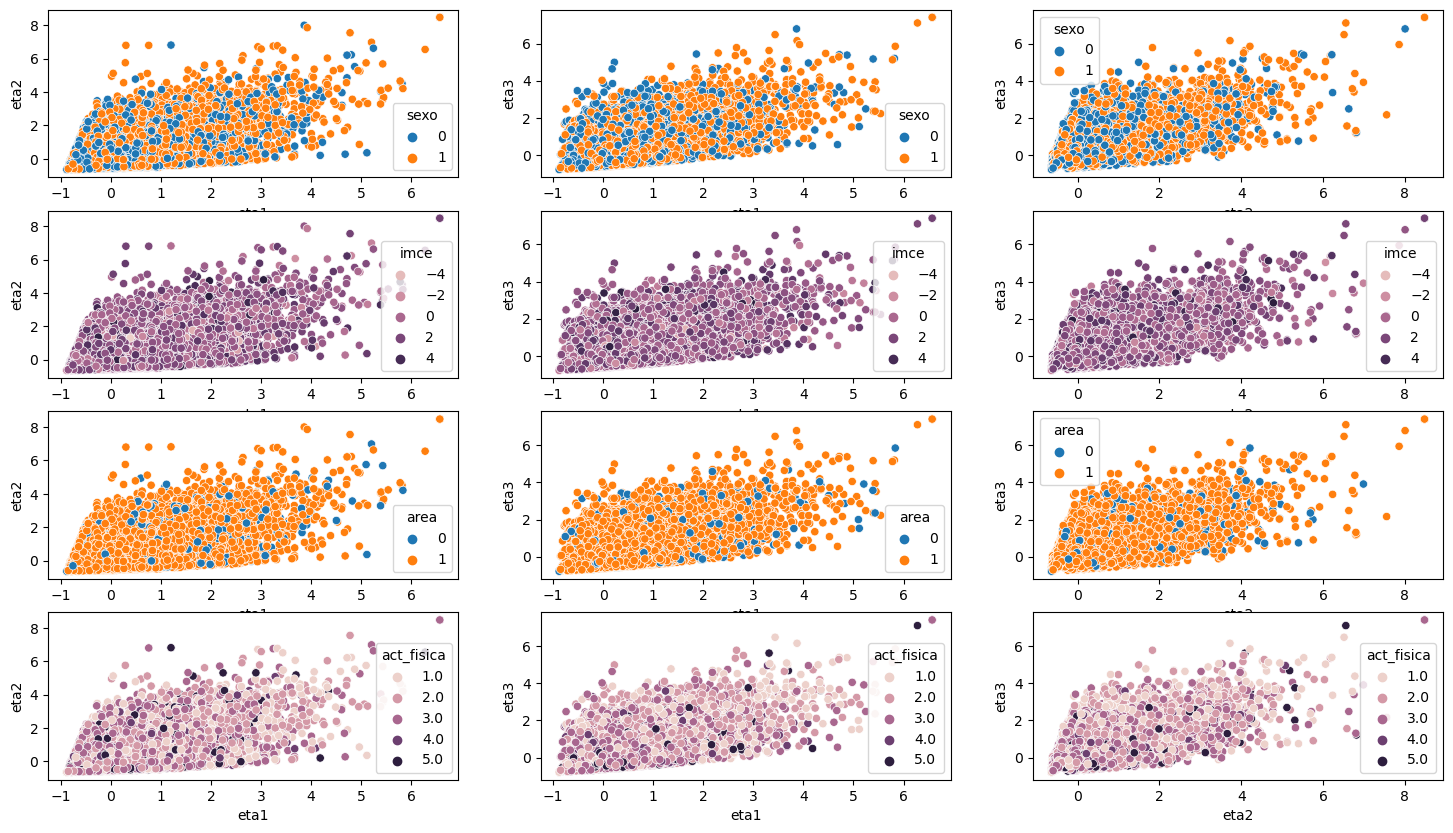

In [19]:

fig, axs = plt.subplots(4, 3, figsize=(18, 10))  # 1 fila, 3 columnas
sns.scatterplot(data=df, x='eta1', y='eta2', hue='sexo', ax = axs[0,0])
sns.scatterplot(data=df, x='eta1', y='eta3', hue='sexo', ax = axs[0,1])
sns.scatterplot(data=df, x='eta2', y='eta3', hue='sexo', ax = axs[0,2])

sns.scatterplot(data=df, x='eta1', y='eta2', hue='imce', ax = axs[1,0])
sns.scatterplot(data=df, x='eta1', y='eta3', hue='imce', ax = axs[1,1])
sns.scatterplot(data=df, x='eta2', y='eta3', hue='imce', ax = axs[1,2])

sns.scatterplot(data=df, x='eta1', y='eta2', hue='area', ax = axs[2,0])
sns.scatterplot(data=df, x='eta1', y='eta3', hue='area', ax = axs[2,1])
sns.scatterplot(data=df, x='eta2', y='eta3', hue='area', ax = axs[2,2])

sns.scatterplot(data=df, x='eta1', y='eta2', hue='act_fisica', ax = axs[3,0])
sns.scatterplot(data=df, x='eta1', y='eta3', hue='act_fisica', ax = axs[3,1])
sns.scatterplot(data=df, x='eta2', y='eta3', hue='act_fisica', ax = axs[3,2])

<Axes: xlabel='area', ylabel='count'>

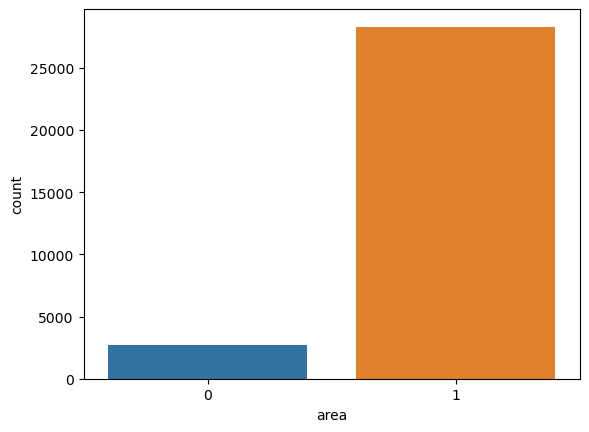

In [20]:
sns.countplot(data=df, x='area')

Al parecer las variables añadidas no muestran ninguna presencia de comportamiento inusual entre los factores, si bien en algunos casos como la variable "area" presentan una mayoria de datos en 1, no hay ninguna muestra de diferenciacion entre las respuestas.

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

In [21]:
mod = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 + sk3 + sk4
eta3 =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(df)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.142
Number of iterations: 42
Params: 1.335 1.233 1.092 1.261 1.793 1.603 1.778 1.027 1.155 0.160 0.057 0.096 0.055 0.165 0.063 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.284


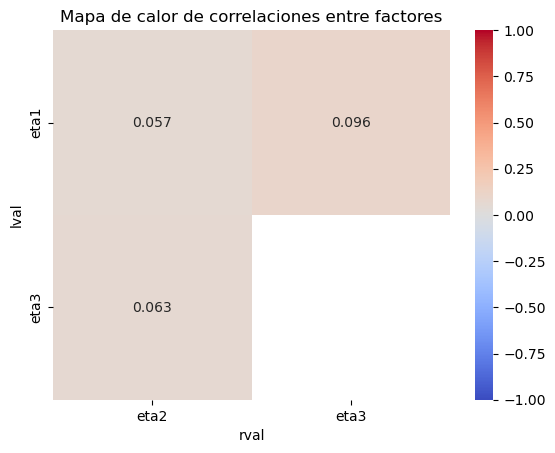

In [22]:
est = model.inspect(std_est=True)
correlaciones = est[
    (est['op'] == '~~') &
    (est['lval'].str.contains('eta')) &
    (est['rval'].str.contains('eta')) &
    (est['lval'] != est['rval'])
]

matriz_corr = correlaciones.pivot(index='lval', columns='rval', values='Estimate')
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones entre factores')
plt.show()

No se ve presencia de correlacion entre cada factor. por lo que podemos conlcuir que cada factor es independiente

In [23]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4401.365973,0.0,87611.052469,0.950307,0.949762,0.934987,0.949762,0.935692,0.052411,53.716544,278.991452,0.141728


El modelo parece ser aceptable.

In [24]:
model.inspect()

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,-,-,-
1,sk10,~,eta1,1.334713,0.017645,75.641962,0.0
2,sk11,~,eta1,1.232807,0.013993,88.102986,0.0
3,sk12,~,eta1,1.091950,0.014832,73.622089,0.0
4,sk13,~,eta1,1.261417,0.017981,70.151539,0.0
5,sk1,~,eta2,1.000000,-,-,-
6,sk2,~,eta2,1.793157,0.021586,83.072223,0.0
7,sk3,~,eta2,1.603422,0.019395,82.673817,0.0
8,sk4,~,eta2,1.777960,0.020174,88.132298,0.0
9,sk5,~,eta3,1.000000,-,-,-


Las variables son significativas para cada uno de sus factores

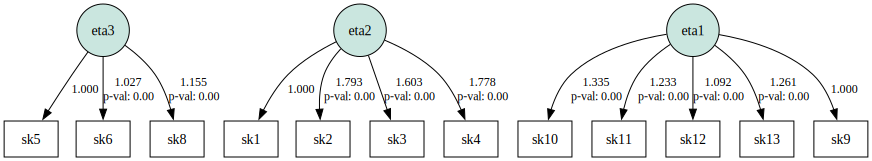

In [25]:
semopy.semplot(model, "model.png")

Viendo el modelo podemos identificar claramente los 3 factores de la siguiente manera:
- eta1 (Interes): Busca comprender las aspiraciones de los niños y sus intereses.
- eta2 (Comunicación): Presenta el comportamiento del niño frente a otras personas, tanto padres como otros niños. 
- eta3 (Grupal): Podemos comprender que tan extrovertido es el niño frente a los grupos de personas. 

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

In [26]:
df = pd.read_csv('../../../data/junaeb3.csv')
df.sk7 = 6 - df.sk7

In [27]:
df.dropna(inplace=True)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.83it/s, max_LL=-1.2e+6, max_avg_LL=-40.3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.17s/it, max_LL=-1.08e+6, max_avg_LL=-36.4]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:21<00:00, 21.78s/it, max_LL=-9.88e+5, max_avg_LL=-33.3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.93s/it, max_LL=-9.96e+5, max_avg_LL=-33.5]


<Axes: >

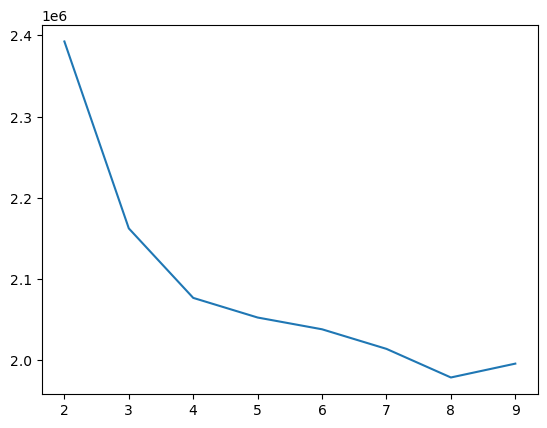

In [28]:
from stepmix.stepmix import StepMix

# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df))

sns.lineplot(x = K, y = BIC)    

Observando el grafico, podemos entender con el metodo del codo que el numero optimo de clusters es 3, casi 4, que es donde la curva empiza a reducir su inclinacion

In [29]:

dfimce=df[['imce']]
from stepmix.stepmix import StepMix
model = StepMix(n_components=4, measurement="gaussian_diag", verbose=1, random_state=123).fit(dfimce)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.62s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                        
          class_no                         0       1       2       3
          param       variable                                      
          covariances imce            1.5910  2.7312  1.5206  0.9168
          means       imce            1.5809 -0.1388  1.7591  0.4413
    Class weights
        Class 1 : 0.25
        Class 2 : 0.09
        Class 3 : 0.26
        Class 4 : 0.40
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 11
    Log-likelihood (LL)           : -51341.1384
    -2LL                          : 102682.2768
    Average LL                    : -1.7289
    AIC                           : 102704.28
    BIC                           : 102795.56
    CAIC                          : 102806.56
    Sample-Size Adjusted BIC  


c:\Users\juana\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [30]:
# Continuous StepMix Model with 3 latent classes
dfmix = df
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(dfimce)
dfmix['pred']=model.predict(dfimce)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.46s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


3 Clusters:
- BIC = 102780
- Entropia relativa = 0.6475

4 Clusters:
- BIC = 102795
- Entropia relativa = 0.2016

Analizando los resultados y lo hablado en clases considero que es mejor agrupar el modelo en 3 clases latentes debido a que aumenta bastante la incertidumbre de la clasificacion cuando se crean 4 clases.

In [31]:
dfmix['pred'] = dfmix['pred'].map({0: 'Clase 1', 1: 'Clase 2', 2: 'Clase 3'})   

Habiendo agrupado las variables en 3 clusters, solo se puede diferenciar que el imce es el unico que se ve alterado de acuerdo a los clusters. tanto el cluster 1 y 2 en promedio cada uno representa uno de los extremos, superior e inferior a la media, y el cluster 3 son los niños que se mantienen al margen del promedio estandarizado.

<Axes: xlabel='pred', ylabel='count'>

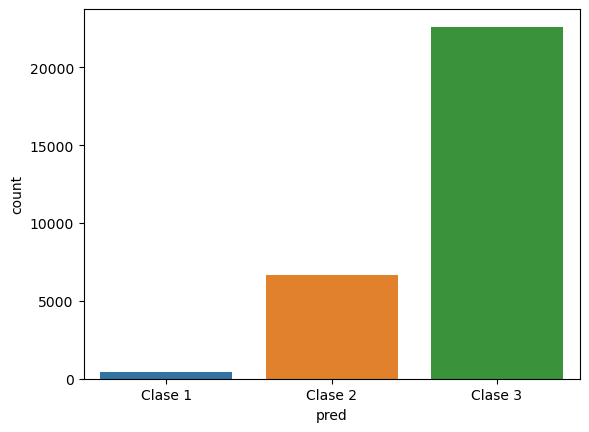

In [32]:
sns.countplot(data=dfmix, x='pred', order=['Clase 1', 'Clase 2', 'Clase 3'])

Al momento de graficar las agrupaciones vemos como en su gran mayoria hay niños pertenecientes al grupo 3 (pertenecientes al promedio del imce). En la clase 2 está la gente que supera por bastante el promedio del imce. Y para finalizar como hemos hablado antes en la clase 1 son las personas con un imce inferior al promedio y el % de estos es bastante bajo en la data por lo que es entendible que haya poca presencia de esa clase, aun asi no menos importante.

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

In [33]:
mod_completo = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13
eta2 =~ sk1 + sk2 + sk3 + sk4
eta3 =~ sk5 + sk6 + sk8

# structural model
imce ~ eta1 + eta2 + eta3 + sexo + area + act_fisica + madre_work + vive_padre + vive_madre + sk7 + educm
"""

al crear la estructura del modelo consideramos ademas de incluir los factores previamente estudiados. Se incluyeron las siguientes variables relevantes para el estudio:
- Sexo: Me interesa conocer si existe alguna diferencia entre los generos de los niños y si esto se relaciona significativamente con el imc
- Area: Aunque desconozco si la densidad de datos llegue a generar alguna alteracion, el conocer las diferencias entre los niños de la capital y los regionales puede ayudar a definir mejor el imc.
- Actividad fisica: A mi parecer es una variable relevante para definir el imc del niño, ademas de la alimentacion el que hagan alguna actividad fisica a la semana deberia ser favorable para la salud del niño
- Madre trabajadora: Puede que el que la amdre trabaje sea un factor importante para decidir el imc del niño, debido a que o lo suple el padre o algun familia/nana o el niño entonces se cuidará solo radicando en un bajo control alimenticio.
- Vive con el padre / madre: Puede que exista una relacion importante el que el hijo viva con alguno de sus padres o no.
- Es agresivo (sk7): Debido a que sk7 no se integro en ningun factor, puede que sea una variable mas independiente lo cual es interesante de analizar de todas formas
- Educación de la madre: se decidió incluir si es que existe alguna diferencia educativa que altere el imc del niño 

In [34]:
mod_completo = semopy.Model(mod_completo)
mod_completo.fit(df)


SolverResult(fun=0.3855787569476554, success=True, n_it=51, x=array([1.347358, 1.247361, 1.097321, 1.272795, 1.878822, 1.646599,
       1.847749, 1.020038, 1.160030, -0.044747, -0.316136, 0.232165,
       0.129453, -0.150233, -0.026022, 0.041706, -0.015396, -0.028990,
       -0.026164, -0.012748, 0.151758, 0.051236, 0.091084, 0.048747,
       0.160560, 0.057273, 1.859856, 0.094998, 0.595399, 0.199771,
       0.441898, 0.713422, 0.241844, 0.199115, 0.158180, 0.150970,
       0.372563, 0.469071, 0.277420]), message='Optimization terminated successfully', name_method='SLSQP', name_obj='MLW')

In [35]:
# Inspeccionar los parámetros estandarizados
mod_completo.inspect(std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.594644,-,-,-
1,sk10,~,eta1,1.347358,0.562439,0.018525,72.730407,0.0
2,sk11,~,eta1,1.247361,0.736000,0.014724,84.716013,0.0
3,sk12,~,eta1,1.097321,0.540876,0.015515,70.727233,0.0
4,sk13,~,eta1,1.272795,0.506248,0.0189,67.342301,0.0
5,sk1,~,eta2,1.000000,0.582339,-,-,-
6,sk2,~,eta2,1.878822,0.644764,0.023823,78.866403,0.0
7,sk3,~,eta2,1.646599,0.631628,0.021137,77.900162,0.0
8,sk4,~,eta2,1.847749,0.716036,0.022197,83.242916,0.0
9,sk5,~,eta3,1.000000,0.717908,-,-,-


In [36]:
# Obtener índices de ajuste
semopy.calc_stats(mod_completo)


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,192,218,11450.146766,0.0,93979.844869,0.879928,0.878164,0.861665,0.878164,0.863669,0.044437,77.228842,400.88078,0.385579


Los indices nos indican que existe un ajuste aceptable al imce, osea que nuestro modelo representa adecuadamente los datos observados.

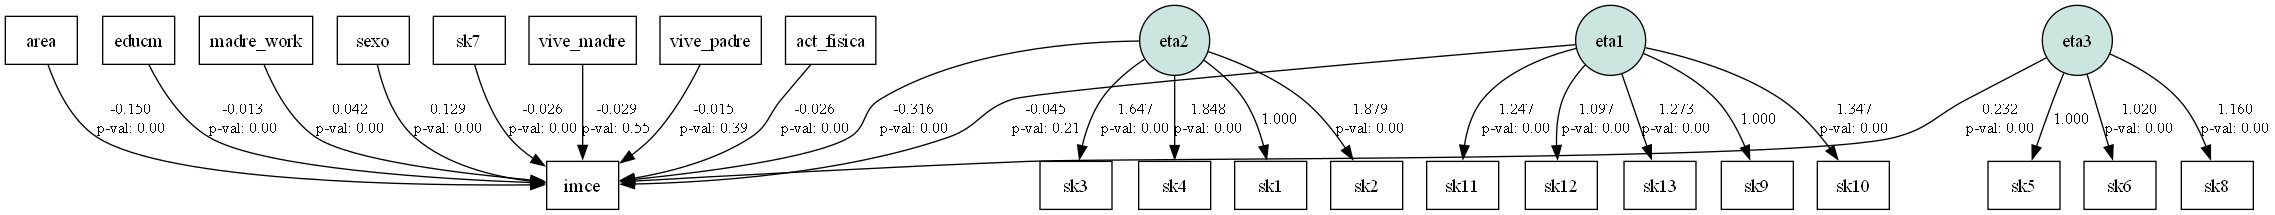

In [37]:
semopy.semplot(mod_completo, "sem_model.png")
from IPython.display import Image
Image("sem_model.png")

Como vemos tanto bastantes variables como factores llegan a ser significativos para el modelo excepto, por ejemplo, el eta1 que nos dice que puede que las aspiraciones del niño realmente no se ven reflejadas en su cuidado en la salud y el imce, asi tambien el si vive con un padre o una madre.

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

In [38]:

# Lista para guardar resultados
resultados = {}

# Ajustar el modelo para cada clase latente
for clase in dfmix['pred'].unique():
    print(f"\nResultados para {clase}:")
    df_sub = dfmix[dfmix['pred'] == clase]
    model = mod_completo
    model.fit(df_sub)
    est = model.inspect(std_est=True)
    stats = semopy.calc_stats(model)
    print(stats[['TLI', 'CFI', 'RMSEA']])
    display(est)
    resultados[clase] = {'params': est, 'fit': stats[['TLI', 'CFI', 'RMSEA']]}

# Ahora puedes comparar los parámetros y el ajuste entre grupos


Resultados para Clase 3:
            TLI       CFI     RMSEA
Value  0.864433  0.880601  0.044232


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.590751,-,-,-
1,sk10,~,eta1,1.345982,0.562236,0.021318,63.137737,0.0
2,sk11,~,eta1,1.251985,0.737784,0.017038,73.479878,0.0
3,sk12,~,eta1,1.088574,0.537638,0.017798,61.163928,0.0
4,sk13,~,eta1,1.248279,0.498535,0.021582,57.838176,0.0
5,sk1,~,eta2,1.000000,0.575363,-,-,-
6,sk2,~,eta2,1.893878,0.641091,0.027821,68.074711,0.0
7,sk3,~,eta2,1.693354,0.639439,0.024913,67.971483,0.0
8,sk4,~,eta2,1.900529,0.719610,0.026322,72.203655,0.0
9,sk5,~,eta3,1.000000,0.714093,-,-,-



Resultados para Clase 2:
            TLI       CFI     RMSEA
Value  0.853703  0.871151  0.046316


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.603327,-,-,-
1,sk10,~,eta1,1.364916,0.563558,0.039081,34.924898,0.0
2,sk11,~,eta1,1.243504,0.730699,0.030547,40.708473,0.0
3,sk12,~,eta1,1.143558,0.550700,0.033295,34.346655,0.0
4,sk13,~,eta1,1.361956,0.530213,0.040781,33.397198,0.0
5,sk1,~,eta2,1.000000,0.610873,-,-,-
6,sk2,~,eta2,1.805114,0.657235,0.046328,38.963719,0.0
7,sk3,~,eta2,1.480311,0.606342,0.040002,37.005701,0.0
8,sk4,~,eta2,1.645449,0.701091,0.040781,40.348175,0.0
9,sk5,~,eta3,1.000000,0.728323,-,-,-



Resultados para Clase 1:
            TLI       CFI     RMSEA
Value  0.801952  0.825573  0.054732


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.667770,-,-,-
1,sk10,~,eta1,1.045991,0.522132,0.119674,8.740331,0.0
2,sk11,~,eta1,1.112385,0.750282,0.098874,11.250481,0.0
3,sk12,~,eta1,0.825103,0.551835,0.090132,9.154385,0.0
4,sk13,~,eta1,1.072491,0.503234,0.126627,8.469678,0.0
5,sk1,~,eta2,1.000000,0.505825,-,-,-
6,sk2,~,eta2,2.465485,0.641766,0.289091,8.528417,0.0
7,sk3,~,eta2,2.203871,0.636511,0.259497,8.492865,0.0
8,sk4,~,eta2,2.775067,0.778978,0.301252,9.211788,0.0
9,sk5,~,eta3,1.000000,0.690967,-,-,-


Al comparar los resultados del modelo visto en cada clase se puede destacar como el que obtiene peores resultados en el TLI, CFI y RMSEA es la clase 1 (Niños con un imce muy bajo), posiblemente debido las pocas observaciones de este grupo reduciendose unos 0.05 puntos en relacion a los demas alejandose aun mas de lo que se podria considerar un modelo aceptable.

Diagrama SEM para Clase 3:


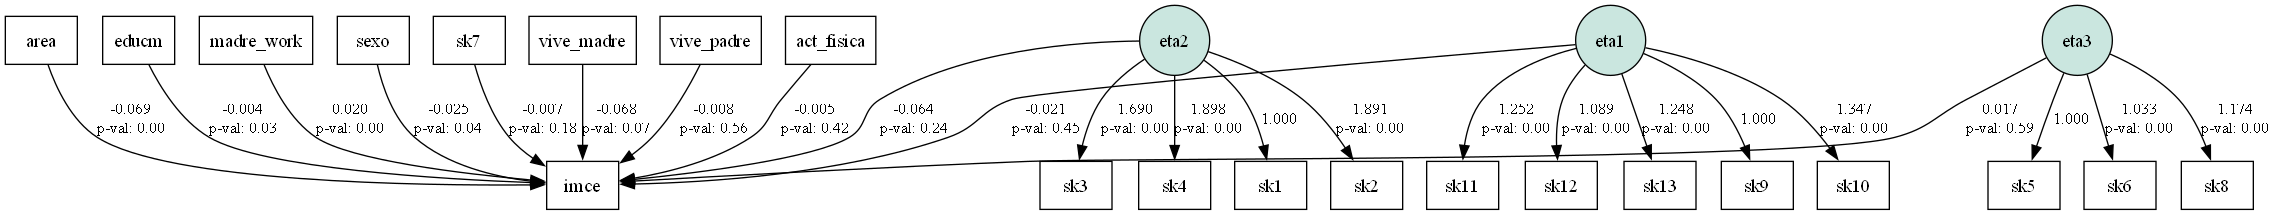

Diagrama SEM para Clase 2:


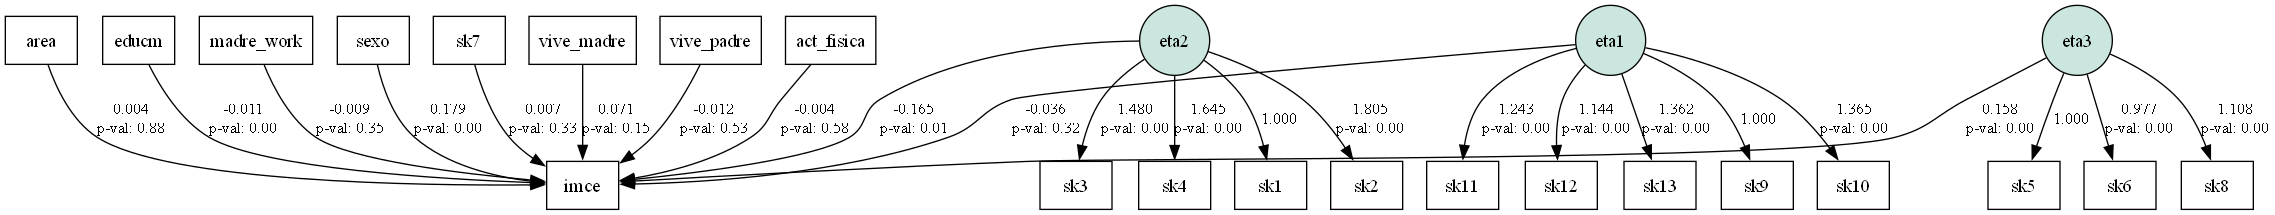

Diagrama SEM para Clase 1:


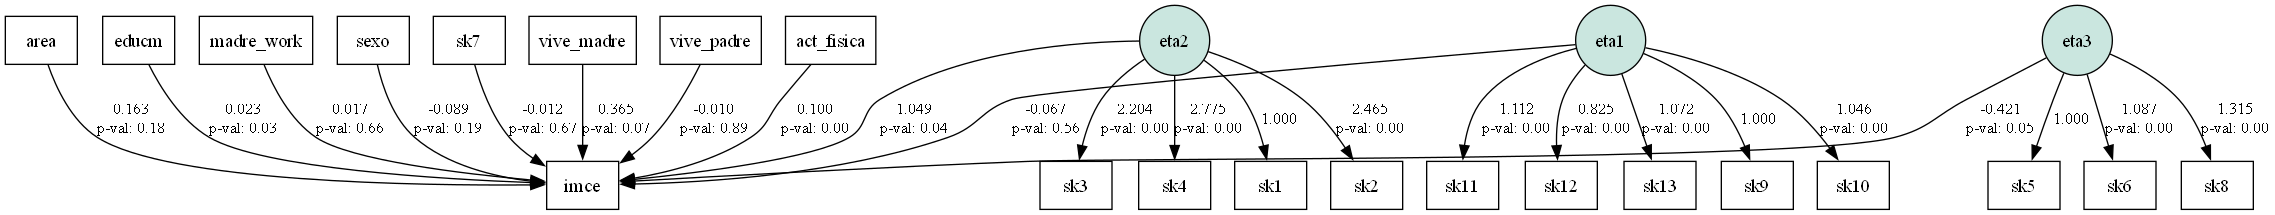

In [39]:
from IPython.display import Image

for clase in dfmix['pred'].unique():
    print(f"Diagrama SEM para {clase}:")
    df_sub = dfmix[dfmix['pred'] == clase]
    model.fit(df_sub)
    filename = f"sem_model_{clase}.png"
    semopy.semplot(model, filename)
    display(Image(filename))
    
#Aunque se clasifican, actividadd fisica no es sifgnificativa cuando son niños ams gorditos es un poco obvio, claramente que no se relaciona, osea la varianza de este en el grupo es muy poca y poco influyente

Además se ve reflejado como dependiendo las clases muchas variables dejan de ser significativas. Algunas conclusiones que se pueden resaltar es que la variable de que la madre trabaje o no deja de ser significativa en las clases 1 y 2 que son los extremos del imc, osea desnutricion y sobrepeso por lo que implica que el que la madre trabaje o no, deja de ser relevante cuando hay presencias de niños que estan en algunos extremos pero si influye favorablemente el que no trabaje cuando un niño pertenece a la clase 1 (dentro del promedio) reduciendo en 0.02 puntos cuando la madre no trabaja y puede controlar mejor lo que consume el infante.

Al parecer el que un niño sea agreviso no es significativo a la hora de estimar su imc en ninguno de los casos. 

Algo que no logro explicar bien es que la actividad fisica solo es significativa en la clase 1 (bajo el imc) y en la clase 3 ninguno de los factores llega a ser significativo.